<a href="https://colab.research.google.com/github/sck2189985/econ8310-assignment4/blob/main/assignment_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pymc as pm
import arviz as az

In [ ]:
url = "https://github.com/dustywhite7/Econ8310/raw/master/AssignmentData/cookie_cats.csv"
df = pd.read_csv(url)

print(df.head())

   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


In [ ]:
df["retention_1"] = df["retention_1"].astype(int)
df["retention_7"] = df["retention_7"].astype(int)

In [ ]:
control = df[df["version"] == "gate_30"]
treatment = df[df["version"] == "gate_40"]

In [ ]:
#summarizing the data
NA = len(control)
YA = control["retention_1"].sum()
NB = len(treatment)
YB = treatment["retention_1"].sum()

print(NA, YA, NB, YB)

44700 20034 45489 20119


In [ ]:
import pymc as pm

with pm.Model() as model:
    # priors
    pA = pm.Uniform("pA", 0, 1)
    pB = pm.Uniform("pB", 0, 1)
    # likelihood
    obs_30 = pm.Bernoulli("obs_30", p=pA, observed=control["retention_1"])
    obs_40 = pm.Bernoulli("obs_40", p=pB, observed=treatment["retention_1"])
    # difference
    delta = pm.Deterministic("delta", pB - pA)
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=False)

Output()

In [ ]:
pA_samples = trace["pA"]
pB_samples = trace["pB"]
delta_samples = trace["delta"]

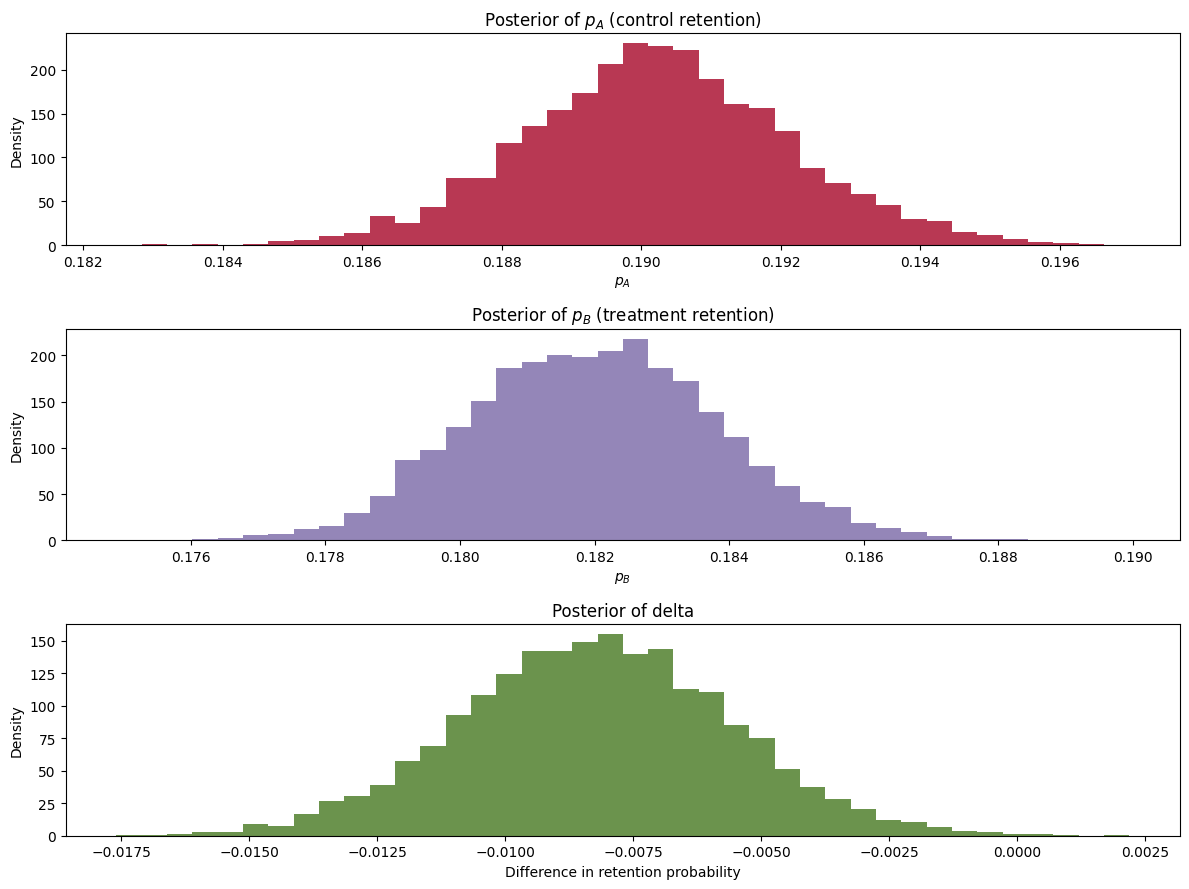

In [ ]:
from matplotlib import pyplot as plt
from IPython.core.pylabtools import figsize

figsize(12, 9)

plt.subplot(311)
plt.hist(pA_samples, bins=40, density=True, alpha=0.8, color="#A60628")
plt.title("Posterior of $p_A$ (control retention)")
plt.xlabel("$p_A$")
plt.ylabel("Density")


plt.subplot(312)
plt.hist(pB_samples, bins=40, density=True, alpha=0.8, color="#7A68A6")
plt.title("Posterior of $p_B$ (treatment retention)")
plt.xlabel("$p_B$")
plt.ylabel("Density")

plt.subplot(313)
plt.hist(delta_samples, bins=40, density=True, alpha=0.8, color="#467821")
plt.title("Posterior of delta")
plt.xlabel("Difference in retention probability")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [ ]:
import pymc as pm

with pm.Model() as model:
    # priors
    pA = pm.Uniform("pA", 0, 1)
    pB = pm.Uniform("pB", 0, 1)
    # likelihood
    obs_30 = pm.Bernoulli("obs_30", p=pA, observed=control["retention_7"])
    obs_40 = pm.Bernoulli("obs_40", p=pB, observed=treatment["retention_7"])
    # difference
    delta = pm.Deterministic("delta", pB - pA)
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=False)

Output()

/usr/local/lib/python3.12/dist-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered 
in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),

In [ ]:
pA_samples = trace["pA"]
pB_samples = trace["pB"]
delta_samples = trace["delta"]

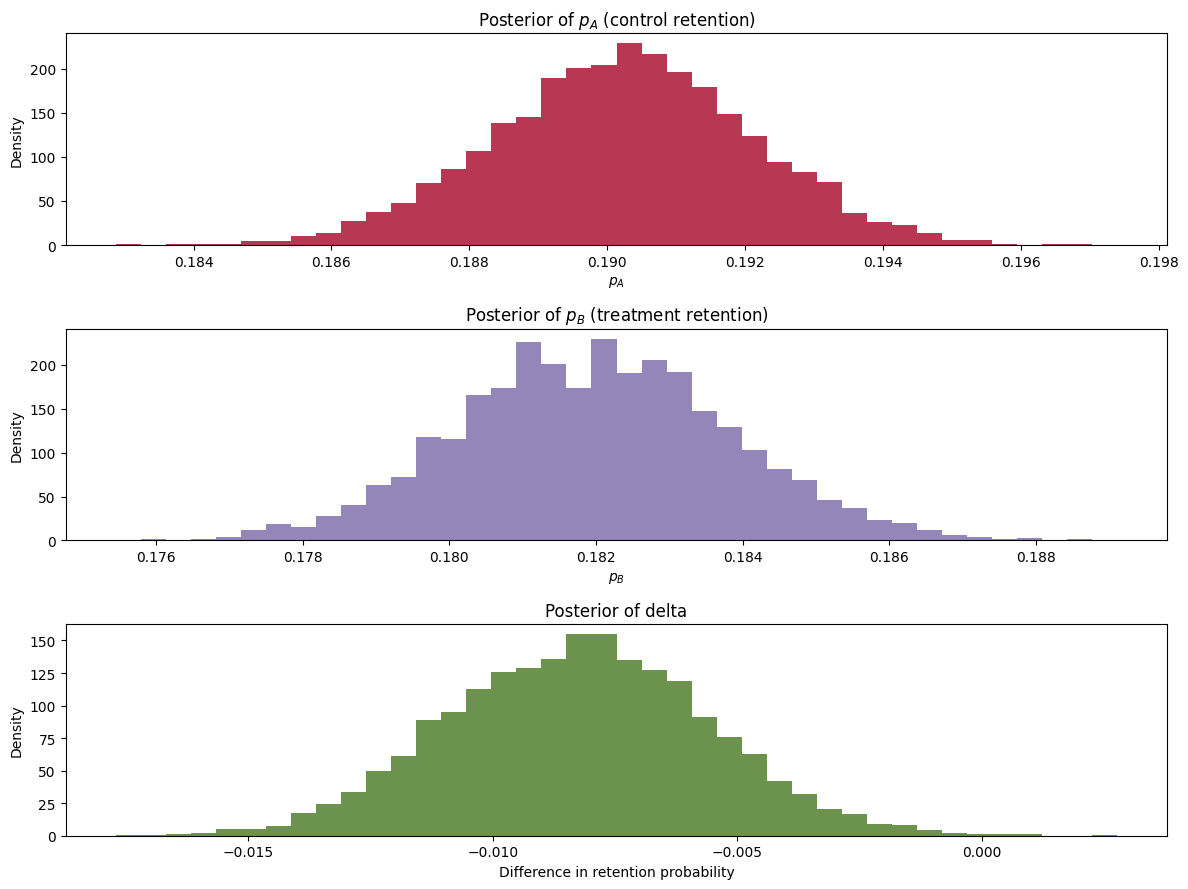

In [ ]:
from matplotlib import pyplot as plt
from IPython.core.pylabtools import figsize

figsize(12, 9)

plt.subplot(311)
plt.hist(pA_samples, bins=40, density=True, alpha=0.8, color="#A60628")
plt.title("Posterior of $p_A$ (control retention)")
plt.xlabel("$p_A$")
plt.ylabel("Density")


plt.subplot(312)
plt.hist(pB_samples, bins=40, density=True, alpha=0.8, color="#7A68A6")
plt.title("Posterior of $p_B$ (treatment retention)")
plt.xlabel("$p_B$")
plt.ylabel("Density")

plt.subplot(313)
plt.hist(delta_samples, bins=40, density=True, alpha=0.8, color="#467821")
plt.title("Posterior of delta")
plt.xlabel("Difference in retention probability")
plt.ylabel("Density")

plt.tight_layout()
plt.show()